# Compare Two Texts Semantically

Paste any two texts below, embed both with a local Ollama embedding model,
and measure how close they are in vector space.

**Pipeline** (same pooling as `embed_indicators.py`, minus the Pine-specific
comment stripping): text -> overlapping chunks -> Ollama embed -> mean-pool ->
normalize.

**Metrics shown**

- *cosine similarity* — 1.0 = same direction, 0 = orthogonal, negative = opposed
- *cosine distance* — `1 - similarity`
- *euclidean distance* — L2 distance between the unit vectors (0 = identical,
  2 = orthogonal); redundant with cosine on normalized vectors but familiar
- *centered cosine* (optional) — subtract the frozen `reference_mean` from the
  model's indicator DB before comparing, like the lineage detector. Only
  meaningful for Pine-ish code; scores are on the calibrated scale
  (remix >= 0.80, related >= 0.50)

**Note:** scores from different models are not comparable.

In [5]:
import sys
from pathlib import Path

import numpy as np

sys.path.insert(0, str(Path.cwd()))
import embed_indicators as ei  # reuse chunking + Ollama client

MODELS_AVAILABLE = ['qwen3-embedding:0.6b', 'qwen3-embedding:4b']


def db_path_for(model):
    if model == 'qwen3-embedding:0.6b':
        return Path('indicator_embeddings.json')
    return ei.default_db_path(model)


def load_reference_mean(model):
    """Frozen corpus mean from the model's indicator DB, or None."""
    import json
    path = db_path_for(model)
    if path.exists():
        db = json.loads(path.read_text())
        if db.get('model') == model and db.get('reference_mean'):
            return np.asarray(db['reference_mean'])
    return None


def embed_text(text, model):
    """Embed arbitrary text: chunk -> embed -> mean-pool -> normalize."""
    ei.MODEL = model
    chunks = ei.chunk_source(text)
    vecs = ei.embed_texts(chunks)
    pooled = vecs.mean(axis=0)
    return pooled / (np.linalg.norm(pooled) + 1e-12), len(chunks)


def compare(text_a, text_b, model, center=False):
    va, na = embed_text(text_a, model)
    vb, nb = embed_text(text_b, model)
    sim = ei.cosine(va, vb)
    result = {
        'model': model,
        'chunks_a': na, 'chunks_b': nb, 'dim': int(va.size),
        'cosine_similarity': sim,
        'cosine_distance': 1.0 - sim,
        'euclidean_distance': float(np.linalg.norm(va - vb)),
        'vec_a': va, 'vec_b': vb,
    }
    if center:
        mu = load_reference_mean(model)
        if mu is not None:
            ca, cb = ei.center(va, mu), ei.center(vb, mu)
            result['centered_cosine'] = ei.cosine(ca, cb)
            result['vec_a'], result['vec_b'] = ca, cb  # plot centered contributions
        else:
            result['centered_cosine'] = None
    return result


def show_contrib(r):
    """Per-dimension contribution + disagreement bar charts, same as
    compare_two_scripts.ipynb. Uses the centered vectors when compare()
    was run with center=True and a reference_mean exists."""
    va, vb = r['vec_a'], r['vec_b']
    centered = r.get('centered_cosine') is not None
    contrib = va * vb                      # sums to cos(a, b) — vectors are unit-norm
    diff2 = (va - vb) ** 2                 # per-dim disagreement; sums to 2 - 2cos
    order = np.argsort(-np.abs(contrib))   # most influential dims first
    pos, neg = contrib[contrib > 0].sum(), contrib[contrib < 0].sum()

    print(f'\n{"centered" if centered else "raw"} cos = {contrib.sum():.4f}   '
          f'agreeing mass={pos:+.4f}   disagreeing mass={neg:+.4f}')
    print(f'top-20 dims carry {contrib[order[:20]].sum() / contrib.sum():.1%} '
          f'of the score')
    try:
        import matplotlib.pyplot as plt
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        ax1.bar(np.arange(len(contrib)), contrib[order], width=1.0)
        ax1.axhline(0, color='k', lw=0.5)
        ax1.set_title(f'A vs B — per-dim contribution a[i]*b[i] '
                      f'({"centered" if centered else "raw"}, sorted by |contrib|, '
                      f'{r["model"]})')
        ax1.set_ylabel('contribution to cosine')
        ax2.bar(np.arange(len(diff2)), diff2[order], width=1.0, color='tomato')
        ax2.set_title('per-dim disagreement (a[i]-b[i])² (same dim order)')
        ax2.set_ylabel('squared diff')
        ax2.set_xlabel('dimension rank (not dimension id)')
        plt.tight_layout()
        plt.show()
    except ImportError:
        print('matplotlib not installed — top-20 dims instead:')
        for d in order[:20]:
            print(f'  dim {d:>4}: a={va[d]:+.4f} b={vb[d]:+.4f} '
                  f'contrib={contrib[d]:+.5f} diff2={diff2[d]:.5f}')

model             qwen3-embedding:0.6b   (dim=1024, chunks: A=1, B=1)
--------------------------------------------------------
cosine similarity     1.0000
cosine distance       0.0000
euclidean distance    0.0000

raw cos = 1.0000   agreeing mass=+1.0000   disagreeing mass=+0.0000
top-20 dims carry 16.0% of the score


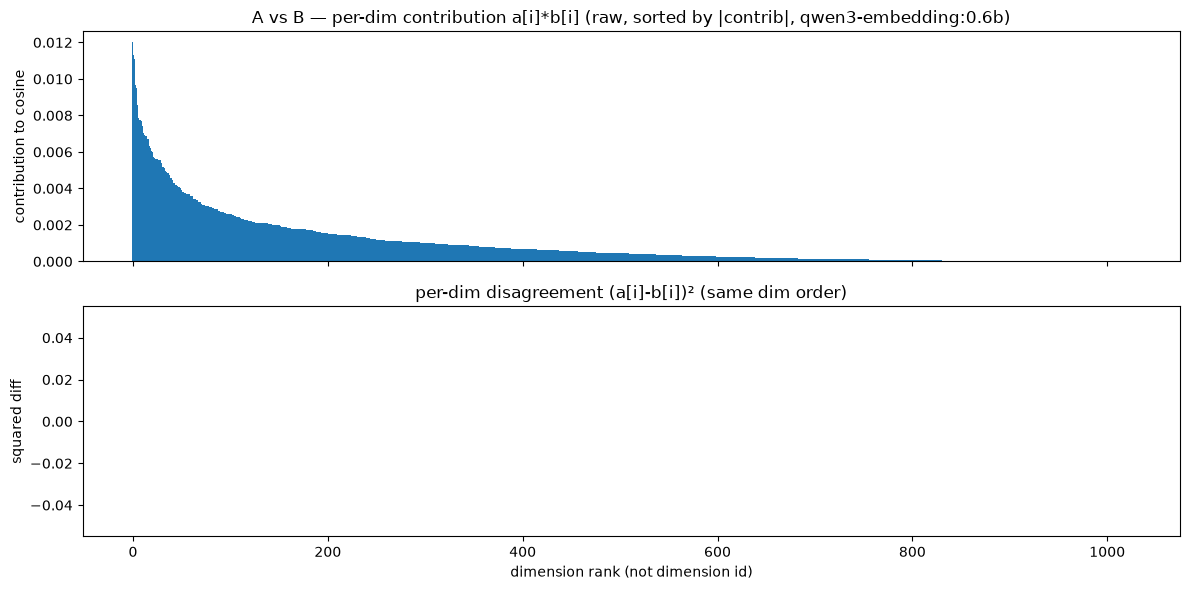

In [6]:
TEXT_A = """Method
Place the crumpet fingers in a bowl, drizzle over the melted butter and stir to coat the crumpets.

Mix the sugar and cinnamon together in a separate bowl, and then sprinkle onto the crumpet fingers.

Mix everything together then place in the air fryer for 5–6 minutes at 180C.

To make the sauce, whisk all of the ingredients in a pan and heat until it thickens, around 5 minutes.

Add extra sugar and cinnamon to the churros to taste, and serve alongside the chocolate sauce for dipping."""
TEXT_B = """Method
Place the crumpet fingers in a bowl, drizzle over the melted butter and stir to coat the crumpets.

Mix the sugar and cinnamon together in a separate bowl, and then sprinkle onto the crumpet fingers.

Mix everything together then place in the air fryer for 5–6 minutes at 180C.

To make the sauce, whisk all of the ingredients in a pan and heat until it thickens, around 5 minutes.

Add extra sugar and cinnamon to the churros to taste, and serve alongside the chocolate sauce for dipping."""

MODEL = 'qwen3-embedding:0.6b'
CENTER = False  # subtract the indicator DB's reference_mean (Pine scripts only)

try:
    r = compare(TEXT_A, TEXT_B, MODEL, CENTER)
except SystemExit as e:  # Ollama down / model not pulled
    print(e)
else:
    print(f'model             {r["model"]}   (dim={r["dim"]}, '
          f'chunks: A={r["chunks_a"]}, B={r["chunks_b"]})')
    print('-' * 56)
    print(f'cosine similarity   {r["cosine_similarity"]:>8.4f}')
    print(f'cosine distance     {r["cosine_distance"]:>8.4f}')
    print(f'euclidean distance  {r["euclidean_distance"]:>8.4f}')
    if 'centered_cosine' in r:
        if r['centered_cosine'] is None:
            print('centered cosine      n/a (no reference_mean in DB)')
        else:
            c = r['centered_cosine']
            tag = ('REMIX?' if c >= ei.REMIX_THRESHOLD
                   else 'related' if c >= ei.RELATED_THRESHOLD else '')
            print(f'centered cosine     {c:>8.4f}  {tag}')
    show_contrib(r)

In [7]:
import ipywidgets as widgets
from IPython.display import display

model_dd = widgets.Dropdown(
    options=MODELS_AVAILABLE, value=MODELS_AVAILABLE[0], description='model:',
    layout=widgets.Layout(width='380px'), style={'description_width': '55px'})
center_cb = widgets.Checkbox(
    value=False, description='center by corpus mean (Pine scripts only)',
    indent=False, layout=widgets.Layout(width='340px'))
text_a = widgets.Textarea(
    placeholder='Text A — paste anything (code, prose, prompt)',
    description='A:',
    layout=widgets.Layout(width='620px', height='180px'),
    style={'description_width': '25px'})
text_b = widgets.Textarea(
    placeholder='Text B',
    description='B:',
    layout=widgets.Layout(width='620px', height='180px'),
    style={'description_width': '25px'})
go = widgets.Button(description='Compare', button_style='primary',
                    layout=widgets.Layout(width='140px'))
out = widgets.Output()


def on_compare(_):
    out.clear_output()
    with out:
        a, b = text_a.value, text_b.value
        if not a.strip() or not b.strip():
            print('Both texts must be non-empty.')
            return
        print(f'embedding with {model_dd.value} ...', flush=True)
        try:
            r = compare(a, b, model_dd.value, center_cb.value)
        except SystemExit as e:  # Ollama down / model not pulled
            print(e)
            return
        out.clear_output()
        print(f'model             {r["model"]}   (dim={r["dim"]}, '
              f'chunks: A={r["chunks_a"]}, B={r["chunks_b"]})')
        print('-' * 56)
        print(f'cosine similarity   {r["cosine_similarity"]:>8.4f}')
        print(f'cosine distance     {r["cosine_distance"]:>8.4f}')
        print(f'euclidean distance  {r["euclidean_distance"]:>8.4f}')
        if 'centered_cosine' in r:
            if r['centered_cosine'] is None:
                print('centered cosine      n/a (no reference_mean in DB)')
            else:
                c = r['centered_cosine']
                tag = ('REMIX?' if c >= ei.REMIX_THRESHOLD
                       else 'related' if c >= ei.RELATED_THRESHOLD else '')
                print(f'centered cosine     {c:>8.4f}  {tag}')
        show_contrib(r)


go.on_click(on_compare)
display(widgets.HBox([model_dd, center_cb, go]), text_a, text_b, out)

Textarea(value='', description='A:', layout=Layout(height='180px', width='620px'), placeholder='Text A — paste…

Textarea(value='', description='B:', layout=Layout(height='180px', width='620px'), placeholder='Text B', style…

Output()